In [8]:
import pandas as pd
import numpy as np

pop = pd.read_csv('유동인구.csv', encoding='cp949')
sales = pd.read_csv('추정매출.csv', encoding='cp949')

null_pop = pop.isnull().sum()
null_sales = sales.isnull().sum()
print(null_pop[null_pop > 0])
print(null_sales[null_sales > 0])


Series([], dtype: int64)
Series([], dtype: int64)


In [9]:
# 서비스 업종 코드 명을 각각 확인해봄
print(sales["서비스_업종_코드_명"].unique())

<StringArray>
[        '조명용품',         '인테리어',          '철물점',           '가구',
         '애완동물',           '화초',         '섬유제품',           '완구',
 '자전거 및 기타운송장비',      '운동/경기용품',          '화장품',           '문구',
           '서적',         '의료기기',          '의약품',       '시계및귀금속',
           '안경',         '일반의류',         '반찬가게',          '청과상',
         '육류판매',   '컴퓨터및주변장치판매',          '편의점',         '슈퍼마켓',
          '노래방',           '여관',          '세탁소',        '피부관리실',
          '미용실',        '자동차미용',        '자동차수리',        '스포츠클럽',
          'PC방',        '골프연습장',          '당구장',          '한의원',
         '치과의원',       '스포츠 강습',         '예술학원',       '일반교습학원',
        '커피-음료',      '호프-간이주점',        '분식전문점',        '치킨전문점',
       '패스트푸드점',          '제과점',        '양식음식점',        '중식음식점',
        '한식음식점',         '일반의원',        '외국어학원',        '일식음식점',
           '가방',           '신발',        '수산물판매',         '미곡판매',
          '핸드폰',       '가전제품수리',          '네일숍',       '전자상거래업',
         '가

In [ ]:
# 이제 서비스 업종 코드 명이 '커피-음료'인 데이터만 추출해서 분석. 1683개의 데이터가 추출됨
cafe = sales[sales["서비스_업종_코드_명"] == '커피-음료']
print(cafe.shape)
print(cafe["서비스_업종_코드_명"].unique())

(1683, 53)
<StringArray>
['커피-음료']
Length: 1, dtype: str


pandas -> 조회 / 필터 / 정렬 / 집계 / 변형 / 결합 단계로 나뉠 수 있음
다음은 조회와 관련된 메서드들과 출력값들이다.

In [ ]:
print(cafe.head()) # 데이터의 처음 5행을 출력하여 확인 tail() 메서드는 마지막 5행을 출력하여 확인

     기준_년분기_코드    행정동_코드 행정동_코드_명 서비스_업종_코드 서비스_업종_코드_명    당월_매출_금액  당월_매출_건수  \
40       20254  11740700     둔촌2동  CS100010       커피-음료   600915476     79252   
66       20254  11740690     둔촌1동  CS100010       커피-음료   452142858     70417   
118      20254  11740685       길동  CS100010       커피-음료  2740212223    368294   
169      20254  11740660     성내3동  CS100010       커피-음료  1253857753    193859   
219      20254  11740650     성내2동  CS100010       커피-음료  1138806723    182081   

       주중_매출_금액   주말_매출_금액  월요일_매출_금액  ...  시간대_건수~21_매출_건수  시간대_건수~24_매출_건수  \
40    413845253  187070223   69122121  ...            14866             1698   
66    294583863  157558995   45329967  ...            11147             1807   
118  1992648089  747564134  366945122  ...            71457            12140   
169   799868439  453989314  119346028  ...            33574             4136   
219   773338608  365468115  118271446  ...            43978             8822   

     남성_매출_건수  여성_매출_건수  연령대_10_

In [ ]:
print(cafe.info()) # 데이터의 요약 정보를 출력하여 결측치와 데이터 타입을 확인 

<class 'pandas.DataFrame'>
Index: 1683 entries, 40 to 67105
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   기준_년분기_코드        1683 non-null   int64
 1   행정동_코드           1683 non-null   int64
 2   행정동_코드_명         1683 non-null   str  
 3   서비스_업종_코드        1683 non-null   str  
 4   서비스_업종_코드_명      1683 non-null   str  
 5   당월_매출_금액         1683 non-null   int64
 6   당월_매출_건수         1683 non-null   int64
 7   주중_매출_금액         1683 non-null   int64
 8   주말_매출_금액         1683 non-null   int64
 9   월요일_매출_금액        1683 non-null   int64
 10  화요일_매출_금액        1683 non-null   int64
 11  수요일_매출_금액        1683 non-null   int64
 12  목요일_매출_금액        1683 non-null   int64
 13  금요일_매출_금액        1683 non-null   int64
 14  토요일_매출_금액        1683 non-null   int64
 15  일요일_매출_금액        1683 non-null   int64
 16  시간대_00~06_매출_금액  1683 non-null   int64
 17  시간대_06~11_매출_금액  1683 non-null   int64
 18  시간대_11~14_매출_금액  1683 

In [22]:
print(cafe.describe()) # 데이터의 기초 통계량을 확인하여 이상치와 데이터 분포를 파악

          기준_년분기_코드        행정동_코드      당월_매출_금액      당월_매출_건수      주중_매출_금액  \
count   1683.000000  1.683000e+03  1.683000e+03  1.683000e+03  1.683000e+03   
mean   20252.500891  1.143332e+07  1.738881e+09  2.229076e+05  1.295831e+09   
std        1.118100  1.917676e+05  3.538274e+09  4.045937e+05  2.792426e+09   
min    20251.000000  1.111052e+07  2.506870e+05  2.800000e+01  1.890940e+05   
25%    20252.000000  1.126066e+07  2.588835e+08  4.021850e+04  1.766609e+08   
50%    20253.000000  1.144066e+07  6.707655e+08  9.712900e+04  4.592092e+08   
75%    20253.500000  1.159068e+07  1.692560e+09  2.350585e+05  1.173581e+09   
max    20254.000000  1.174070e+07  3.864487e+10  4.411009e+06  3.086914e+10   

           주말_매출_금액     월요일_매출_금액     화요일_매출_금액     수요일_매출_금액     목요일_매출_금액  \
count  1.683000e+03  1.683000e+03  1.683000e+03  1.683000e+03  1.683000e+03   
mean   4.430496e+08  2.370373e+08  2.534329e+08  2.655669e+08  2.644839e+08   
std    8.512859e+08  5.112960e+08  5.561995e+08  5.

In [25]:
print(cafe.columns)
print(cafe.shape)

Index(['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '서비스_업종_코드', '서비스_업종_코드_명',
       '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '월요일_매출_금액',
       '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액',
       '일요일_매출_금액', '시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
       '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액', '남성_매출_금액',
       '여성_매출_금액', '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
       '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액', '주중_매출_건수',
       '주말_매출_건수', '월요일_매출_건수', '화요일_매출_건수', '수요일_매출_건수', '목요일_매출_건수',
       '금요일_매출_건수', '토요일_매출_건수', '일요일_매출_건수', '시간대_건수~06_매출_건수',
       '시간대_건수~11_매출_건수', '시간대_건수~14_매출_건수', '시간대_건수~17_매출_건수',
       '시간대_건수~21_매출_건수', '시간대_건수~24_매출_건수', '남성_매출_건수', '여성_매출_건수',
       '연령대_10_매출_건수', '연령대_20_매출_건수', '연령대_30_매출_건수', '연령대_40_매출_건수',
       '연령대_50_매출_건수', '연령대_60_이상_매출_건수'],
      dtype='str')
(1683, 53)


In [15]:
cafe["당월_매출_금액"].sum()
cafe["당월_매출_금액"].mean()

np.float64(1738880992.6589425)

위 코드를 보면 분명 sum 메서드와 mean 메서드를 써주었지만 마지막 줄만 출력되는 것을 확인함.
jupyter는 마지막 줄만 자동출력됨. 따라서 둘다 보고 싶은 경우 print를 써주어야함. 평균 매출이 무려 17억이다.....

In [17]:
print(cafe["당월_매출_금액"].sum())
print(cafe["당월_매출_금액"].mean())

2926536710645
1738880992.6589425


In [34]:
print(cafe[cafe["당월_매출_금액"] > 1738880992.6589425])
print(cafe[cafe["당월_매출_금액"] > 1738880992.6589425].shape[0]) 

       기준_년분기_코드    행정동_코드     행정동_코드_명 서비스_업종_코드 서비스_업종_코드_명     당월_매출_금액  \
118        20254  11740685           길동  CS100010       커피-음료   2740212223   
361        20254  11740610         천호2동  CS100010       커피-음료   2006589685   
621        20254  11740540         명일2동  CS100010       커피-음료   2004207796   
788        20254  11710710         잠실6동  CS100010       커피-음료   7178615162   
849        20254  11710680         잠실3동  CS100010       커피-음료   1819133021   
...          ...       ...          ...       ...         ...          ...   
66905      20251  11110615  종로1?2?3?4가동  CS100010       커피-음료  20926268155   
66929      20251  11110600          가회동  CS100010       커피-음료   4495728193   
67031      20251  11110540          삼청동  CS100010       커피-음료   5548781022   
67072      20251  11110530          사직동  CS100010       커피-음료   9462371274   
67105      20251  11110515        청운효자동  CS100010       커피-음료   4535266422   

       당월_매출_건수     주중_매출_금액    주말_매출_금액   월요일_매출_금액  ...  시간대_

In [33]:
print(cafe[cafe["당월_매출_금액"] > cafe["당월_매출_금액"].mean()]) 
print(cafe[cafe["당월_매출_금액"] > cafe["당월_매출_금액"].mean()].shape[0]) # 평균보다 매출이 높은 데이터의 개수

       기준_년분기_코드    행정동_코드     행정동_코드_명 서비스_업종_코드 서비스_업종_코드_명     당월_매출_금액  \
118        20254  11740685           길동  CS100010       커피-음료   2740212223   
361        20254  11740610         천호2동  CS100010       커피-음료   2006589685   
621        20254  11740540         명일2동  CS100010       커피-음료   2004207796   
788        20254  11710710         잠실6동  CS100010       커피-음료   7178615162   
849        20254  11710680         잠실3동  CS100010       커피-음료   1819133021   
...          ...       ...          ...       ...         ...          ...   
66905      20251  11110615  종로1?2?3?4가동  CS100010       커피-음료  20926268155   
66929      20251  11110600          가회동  CS100010       커피-음료   4495728193   
67031      20251  11110540          삼청동  CS100010       커피-음료   5548781022   
67072      20251  11110530          사직동  CS100010       커피-음료   9462371274   
67105      20251  11110515        청운효자동  CS100010       커피-음료   4535266422   

       당월_매출_건수     주중_매출_금액    주말_매출_금액   월요일_매출_금액  ...  시간대_

In [ ]:
print(cafe["당월_매출_금액"].max()) # 매출 금액의 최대값
print(cafe["당월_매출_금액"].min()) # 매출 금액의 최소값

38644869363
250687


<Axes: >

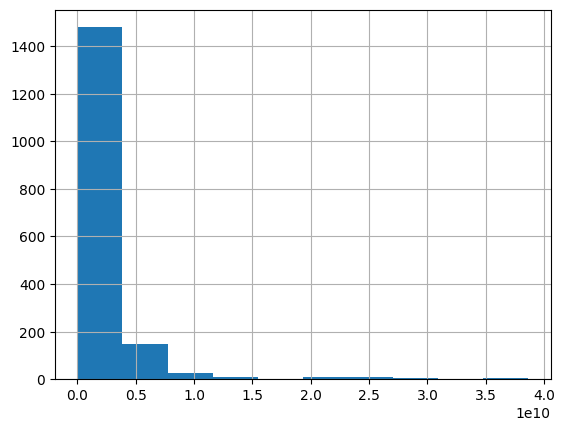

In [35]:
cafe["당월_매출_금액"].hist() # 매출 금액의 분포를 히스토그램으로 시각화